# Heart Disease Dataset - Exploratory Data Analysis (EDA)

This notebook provides a comprehensive exploratory data analysis of the Heart Disease dataset.

## Table of Contents
1. Data Loading and Initial Inspection
2. Dataset Overview
3. Statistical Summary
4. Missing Values Analysis
5. Data Distribution Analysis
6. Correlation Analysis
7. Univariate Analysis
8. Bivariate Analysis
9. Target Variable Analysis
10. Insights and Conclusions

In [4]:
!python -m pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Loading and Initial Inspection

In [2]:
# Import necessary libraries
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries imported successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


In [5]:
# Load the dataset
df = pd.read_csv('Dataset/Heart_Disease.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (1190, 12)


In [6]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.000,1,0
1,49,0,3,160,180,0,0,156,0,1.000,2,1
2,37,1,2,130,283,0,1,98,0,0.000,1,0
3,48,0,4,138,214,0,0,108,1,1.500,2,1
4,54,1,3,150,195,0,0,122,0,0.000,1,0
5,39,1,3,120,339,0,0,170,0,0.000,1,0
6,45,0,2,130,237,0,0,170,0,0.000,1,0
7,54,1,2,110,208,0,0,142,0,0.000,1,0
8,37,1,4,140,207,0,0,130,1,1.500,2,1
9,48,0,2,120,284,0,0,120,0,0.000,1,0


In [7]:
# Display last few rows
print("Last 5 rows of the dataset:")
df.tail()

Last 5 rows of the dataset:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1185,45,1,1,110,264,0,0,132,0,1.200,2,1
1186,68,1,4,144,193,1,0,141,0,3.400,2,1
1187,57,1,4,130,131,0,0,115,1,1.200,2,1
1188,57,0,2,130,236,0,2,174,0,0.000,2,1
1189,38,1,3,138,175,0,0,173,0,0.000,1,0


In [8]:
# Random sample
print("Random sample of 10 rows:")
df.sample(10)

Random sample of 10 rows:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1157,61,1,4,140,207,0,2,138,1,1.900,1,1
972,44,1,3,140,235,0,2,180,0,0.000,1,0
163,49,0,2,110,208,0,0,160,0,0.000,1,0
101,51,1,4,130,179,0,0,100,0,0.000,1,0
625,60,1,4,140,293,0,2,170,0,1.200,2,1
428,59,1,4,140,0,0,1,117,1,1.000,2,1
297,50,1,4,145,0,1,0,139,1,0.700,2,1
446,55,1,3,136,228,0,1,124,1,1.600,2,1
1022,55,0,2,135,250,0,2,161,0,1.400,2,0
1047,46,1,2,101,197,1,0,156,0,0.000,1,0


## 2. Dataset Overview

In [9]:
# Dataset information
print("Dataset Information:")
print("="*60)
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [10]:
# Column names
print("Column Names:")
print("="*60)
print(df.columns.tolist())

Column Names:
['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']


In [11]:
# Data types
print("Data Types:")
print("="*60)
print(df.dtypes)

Data Types:
age                      int64
sex                      int64
chest pain type          int64
resting bp s             int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object


In [12]:
# Dataset dimensions
print("Dataset Dimensions:")
print("="*60)
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
print(f"Total cells: {df.shape[0] * df.shape[1]}")

Dataset Dimensions:
Number of Rows: 1190
Number of Columns: 12
Total cells: 14280


## 3. Statistical Summary

In [13]:
# Statistical summary of numerical features
print("Statistical Summary:")
print("="*60)
df.describe()

Statistical Summary:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000
mean,53.720,0.764,3.233,132.154,210.364,0.213,0.698,139.733,0.387,0.923,1.624,0.529
std,9.358,0.425,0.935,18.369,101.420,0.410,0.870,25.518,0.487,1.086,0.610,0.499
min,28.000,0.000,1.000,0.000,0.000,0.000,0.000,60.000,0.000,-2.600,0.000,0.000
25%,47.000,1.000,3.000,120.000,188.000,0.000,0.000,121.000,0.000,0.000,1.000,0.000
50%,54.000,1.000,4.000,130.000,229.000,0.000,0.000,140.500,0.000,0.600,2.000,1.000
75%,60.000,1.000,4.000,140.000,269.750,0.000,2.000,160.000,1.000,1.600,2.000,1.000
max,77.000,1.000,4.000,200.000,603.000,1.000,2.000,202.000,1.000,6.200,3.000,1.000


In [14]:
# Extended statistical summary
print("Extended Statistical Summary (including percentiles):")
print("="*60)
df.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])

Extended Statistical Summary (including percentiles):


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000
mean,53.720,0.764,3.233,132.154,210.364,0.213,0.698,139.733,0.387,0.923,1.624,0.529
std,9.358,0.425,0.935,18.369,101.420,0.410,0.870,25.518,0.487,1.086,0.610,0.499
min,28.000,0.000,1.000,0.000,0.000,0.000,0.000,60.000,0.000,-2.600,0.000,0.000
1%,32.000,0.000,1.000,95.000,0.000,0.000,0.000,79.780,0.000,-0.100,1.000,0.000
5%,38.000,0.000,1.000,106.000,0.000,0.000,0.000,97.000,0.000,0.000,1.000,0.000
10%,41.000,0.000,2.000,110.000,0.000,0.000,0.000,106.000,0.000,0.000,1.000,0.000
25%,47.000,1.000,3.000,120.000,188.000,0.000,0.000,121.000,0.000,0.000,1.000,0.000
50%,54.000,1.000,4.000,130.000,229.000,0.000,0.000,140.500,0.000,0.600,2.000,1.000
75%,60.000,1.000,4.000,140.000,269.750,0.000,2.000,160.000,1.000,1.600,2.000,1.000


In [15]:
# Summary of all columns including categorical
print("Summary of All Columns:")
print("="*60)
df.describe(include='all')

Summary of All Columns:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000,1190.000
mean,53.720,0.764,3.233,132.154,210.364,0.213,0.698,139.733,0.387,0.923,1.624,0.529
std,9.358,0.425,0.935,18.369,101.420,0.410,0.870,25.518,0.487,1.086,0.610,0.499
min,28.000,0.000,1.000,0.000,0.000,0.000,0.000,60.000,0.000,-2.600,0.000,0.000
25%,47.000,1.000,3.000,120.000,188.000,0.000,0.000,121.000,0.000,0.000,1.000,0.000
50%,54.000,1.000,4.000,130.000,229.000,0.000,0.000,140.500,0.000,0.600,2.000,1.000
75%,60.000,1.000,4.000,140.000,269.750,0.000,2.000,160.000,1.000,1.600,2.000,1.000
max,77.000,1.000,4.000,200.000,603.000,1.000,2.000,202.000,1.000,6.200,3.000,1.000


## 4. Missing Values Analysis

In [16]:
# Check for missing values
print("Missing Values Analysis:")
print("="*60)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
})
missing_df = missing_df.sort_values('Missing_Count', ascending=False)
print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values Analysis:
                 Column  Missing_Count  Missing_Percentage
0                   age              0               0.000
1                   sex              0               0.000
2       chest pain type              0               0.000
3          resting bp s              0               0.000
4           cholesterol              0               0.000
5   fasting blood sugar              0               0.000
6           resting ecg              0               0.000
7        max heart rate              0               0.000
8       exercise angina              0               0.000
9               oldpeak              0               0.000
10             ST slope              0               0.000
11               target              0               0.000

Total missing values: 0


In [17]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    plt.bar(range(len(missing_data)), missing_data.values)
    plt.xticks(range(len(missing_data)), missing_data.index, rotation=45, ha='right')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

No missing values found in the dataset!


<Figure size 1200x600 with 0 Axes>

In [18]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 272
Percentage of duplicates: 22.86%


## 5. Data Distribution Analysis

In [19]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical Columns ({len(categorical_cols)}): {categorical_cols}")

Numerical Columns (12): ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']

Categorical Columns (0): []


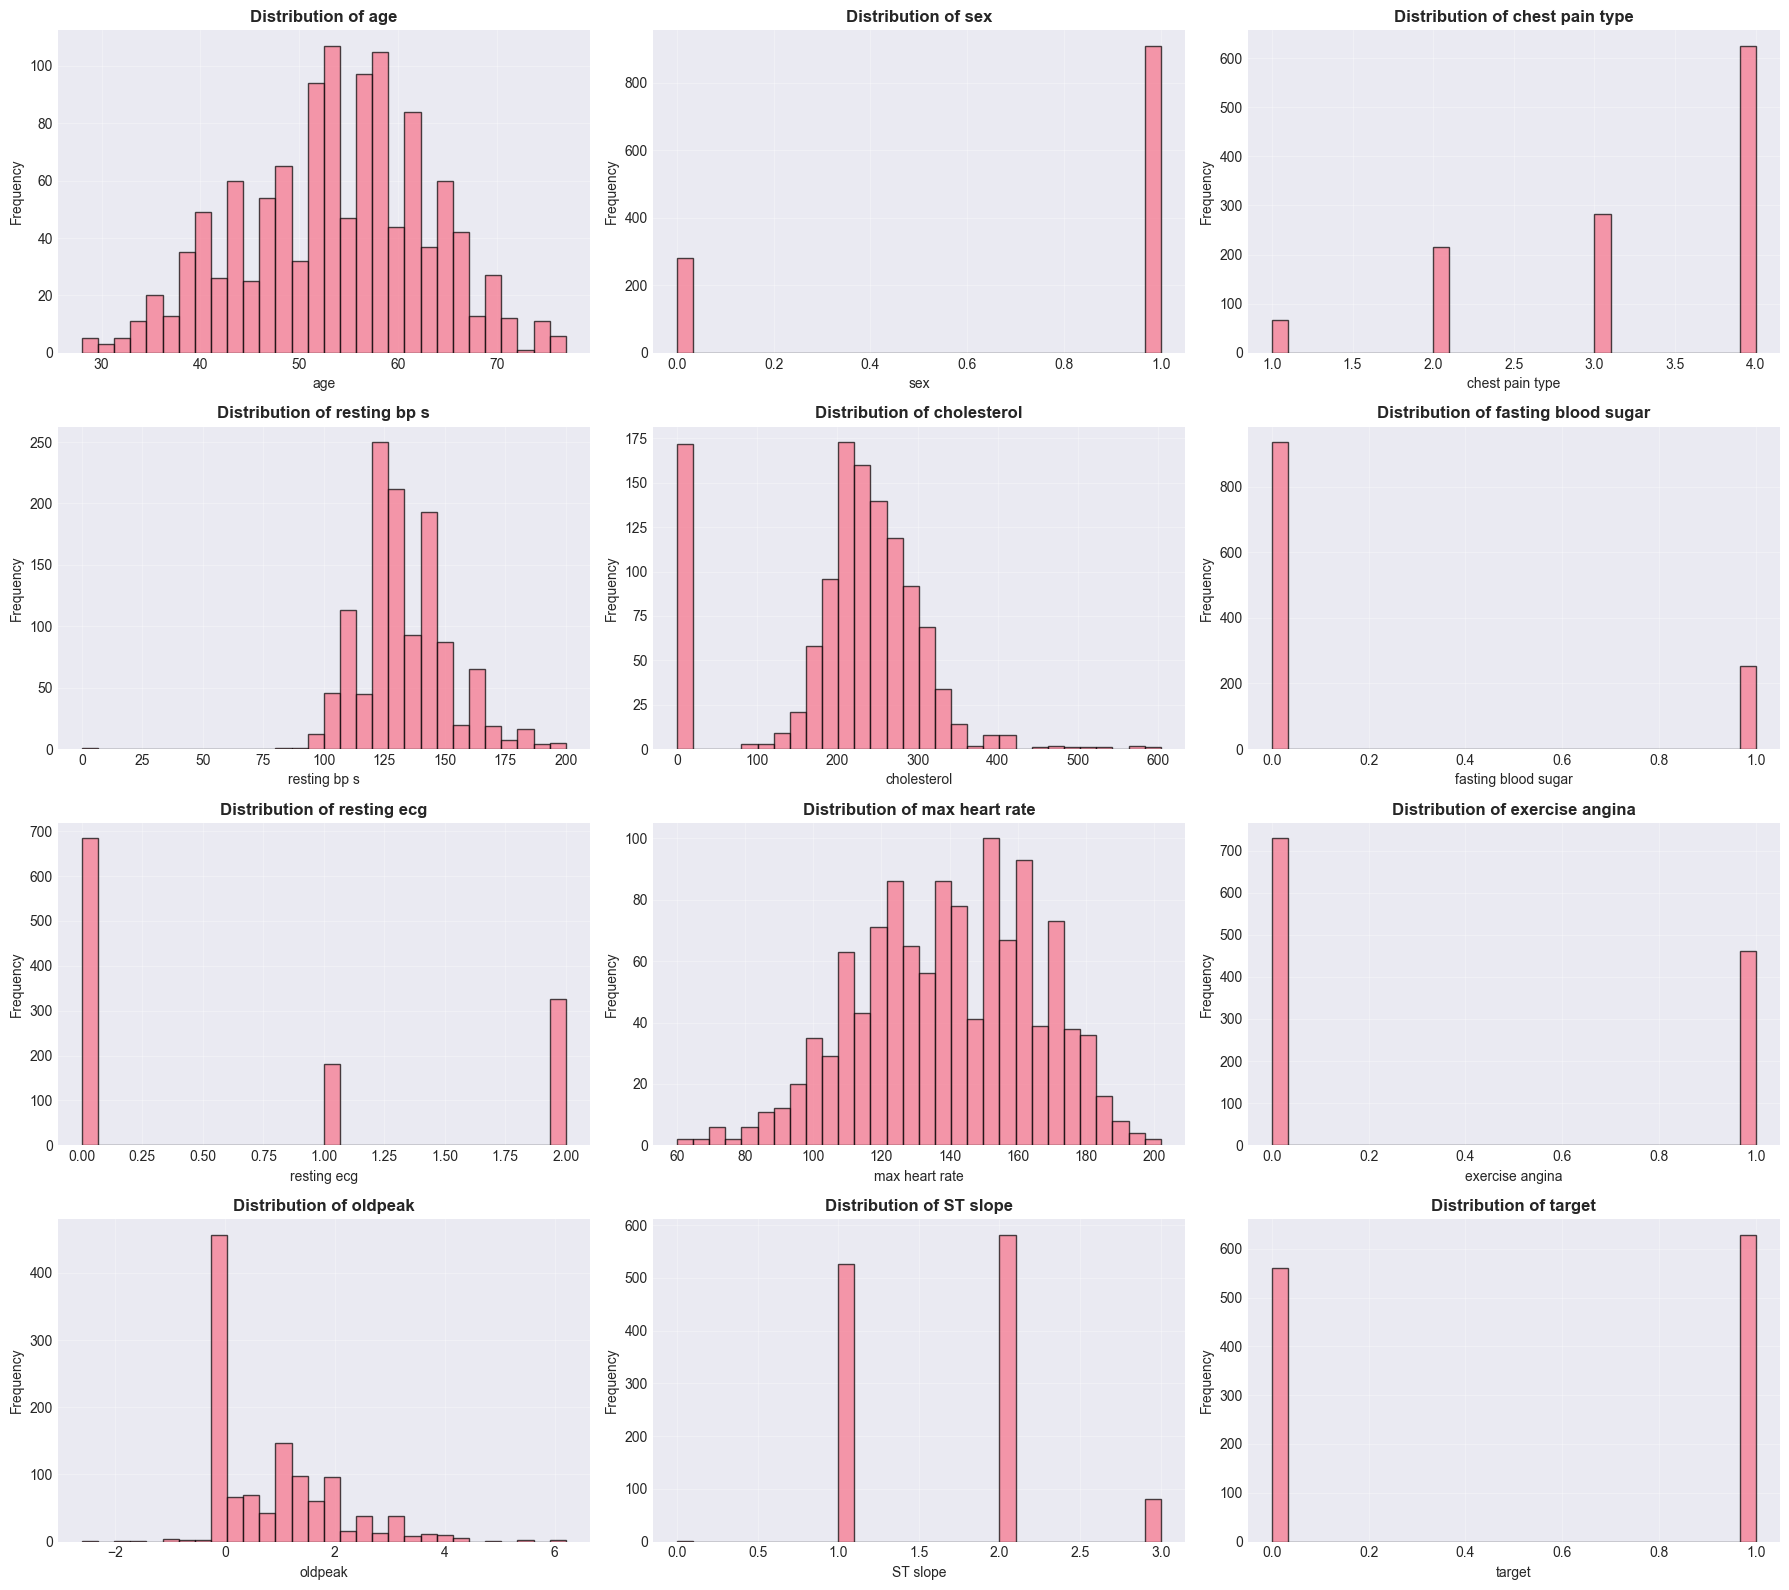

In [20]:
# Distribution of all numerical features
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

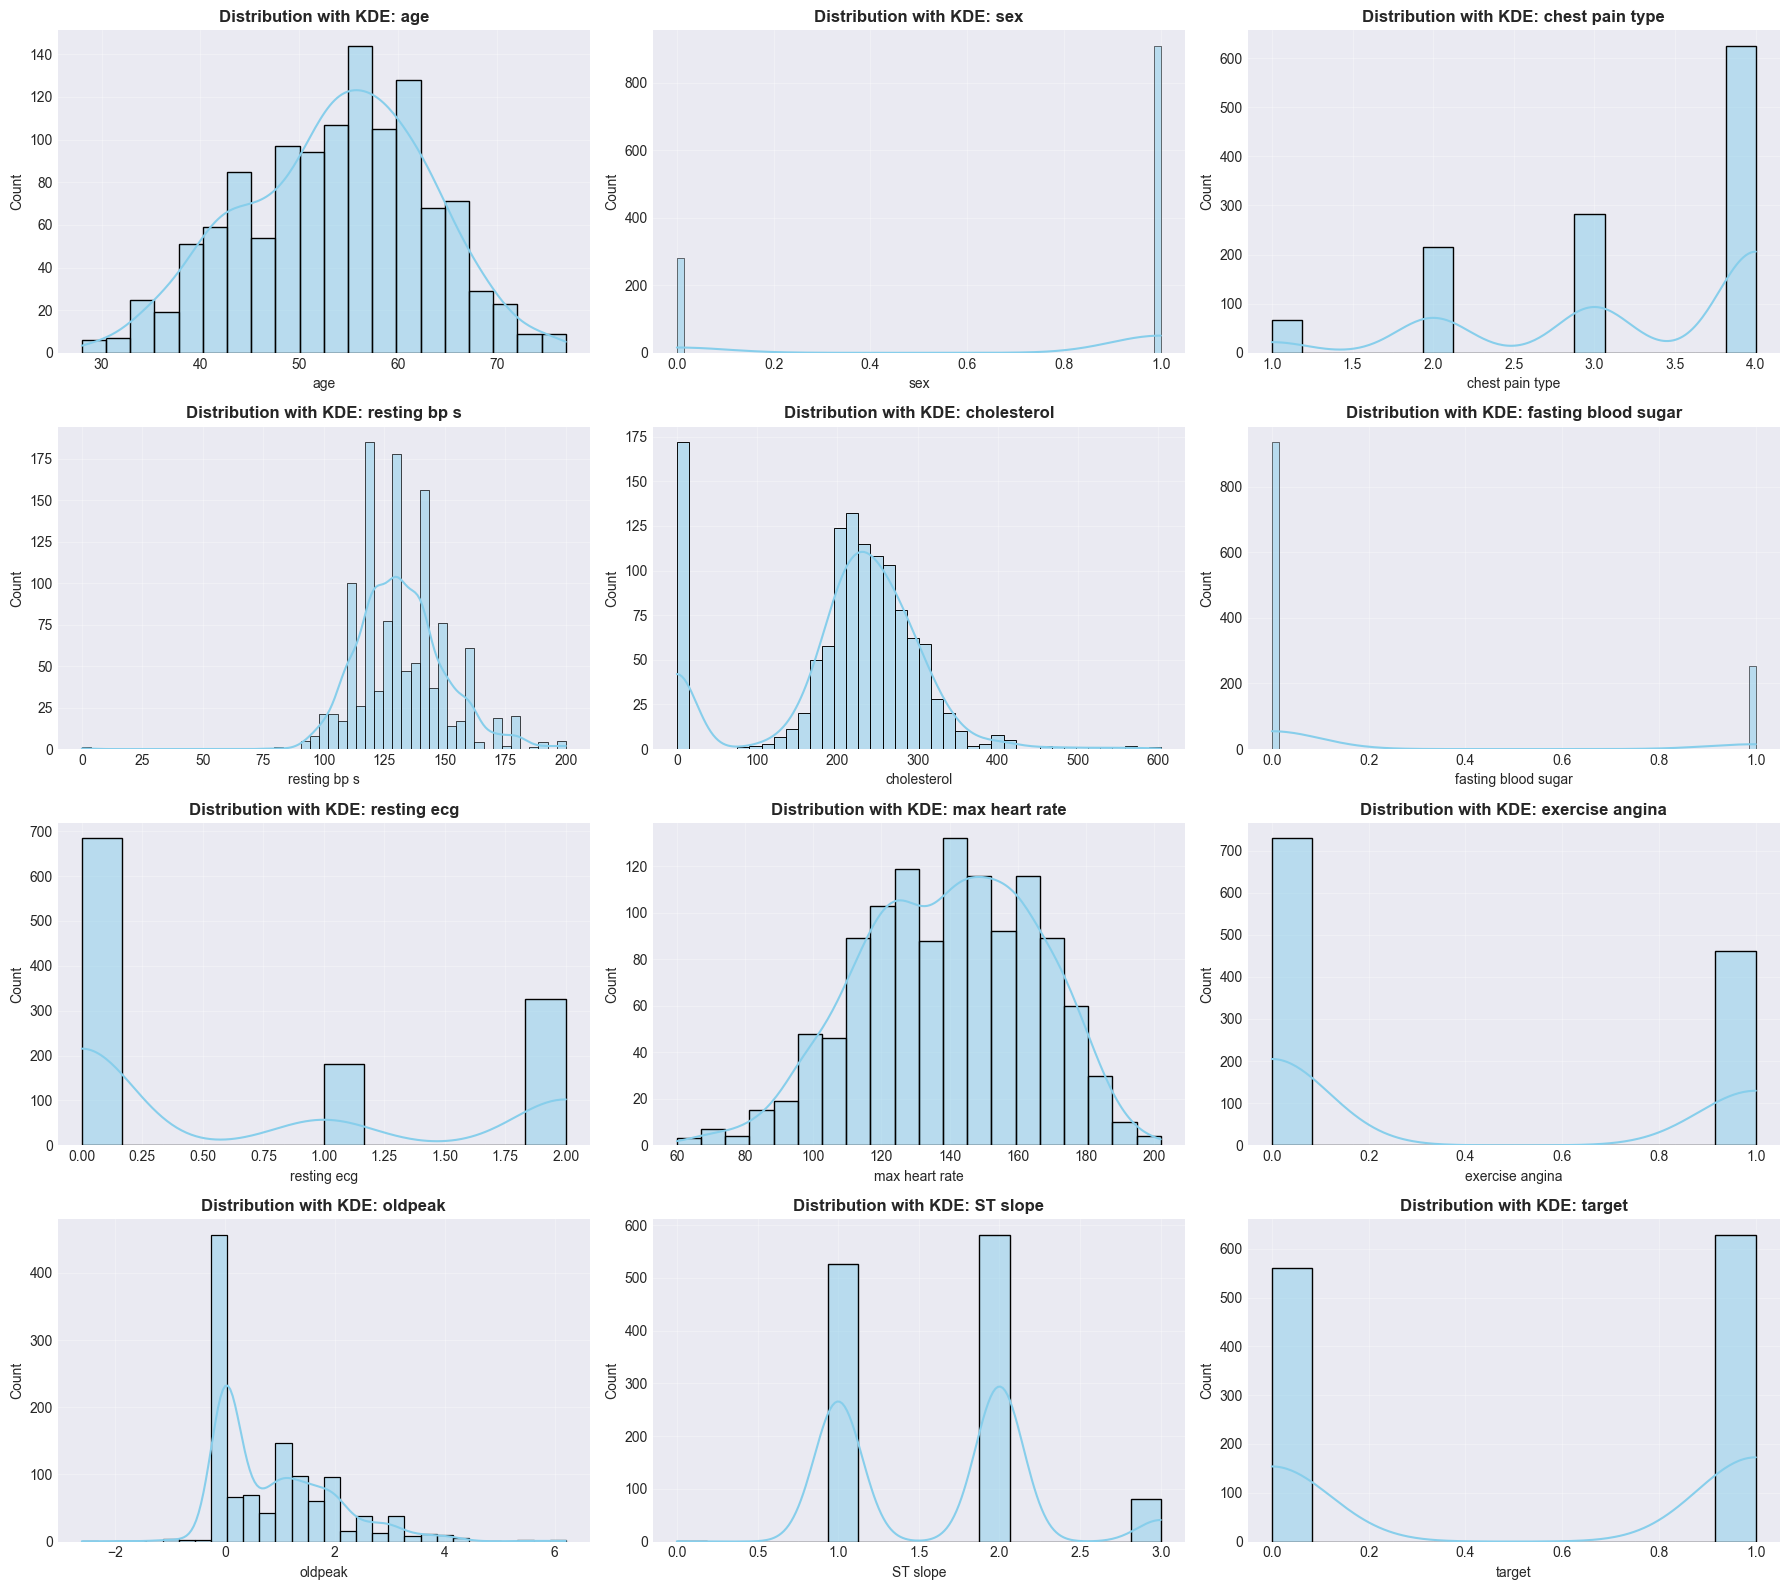

In [21]:
# Distribution plots with KDE
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'Distribution with KDE: {col}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

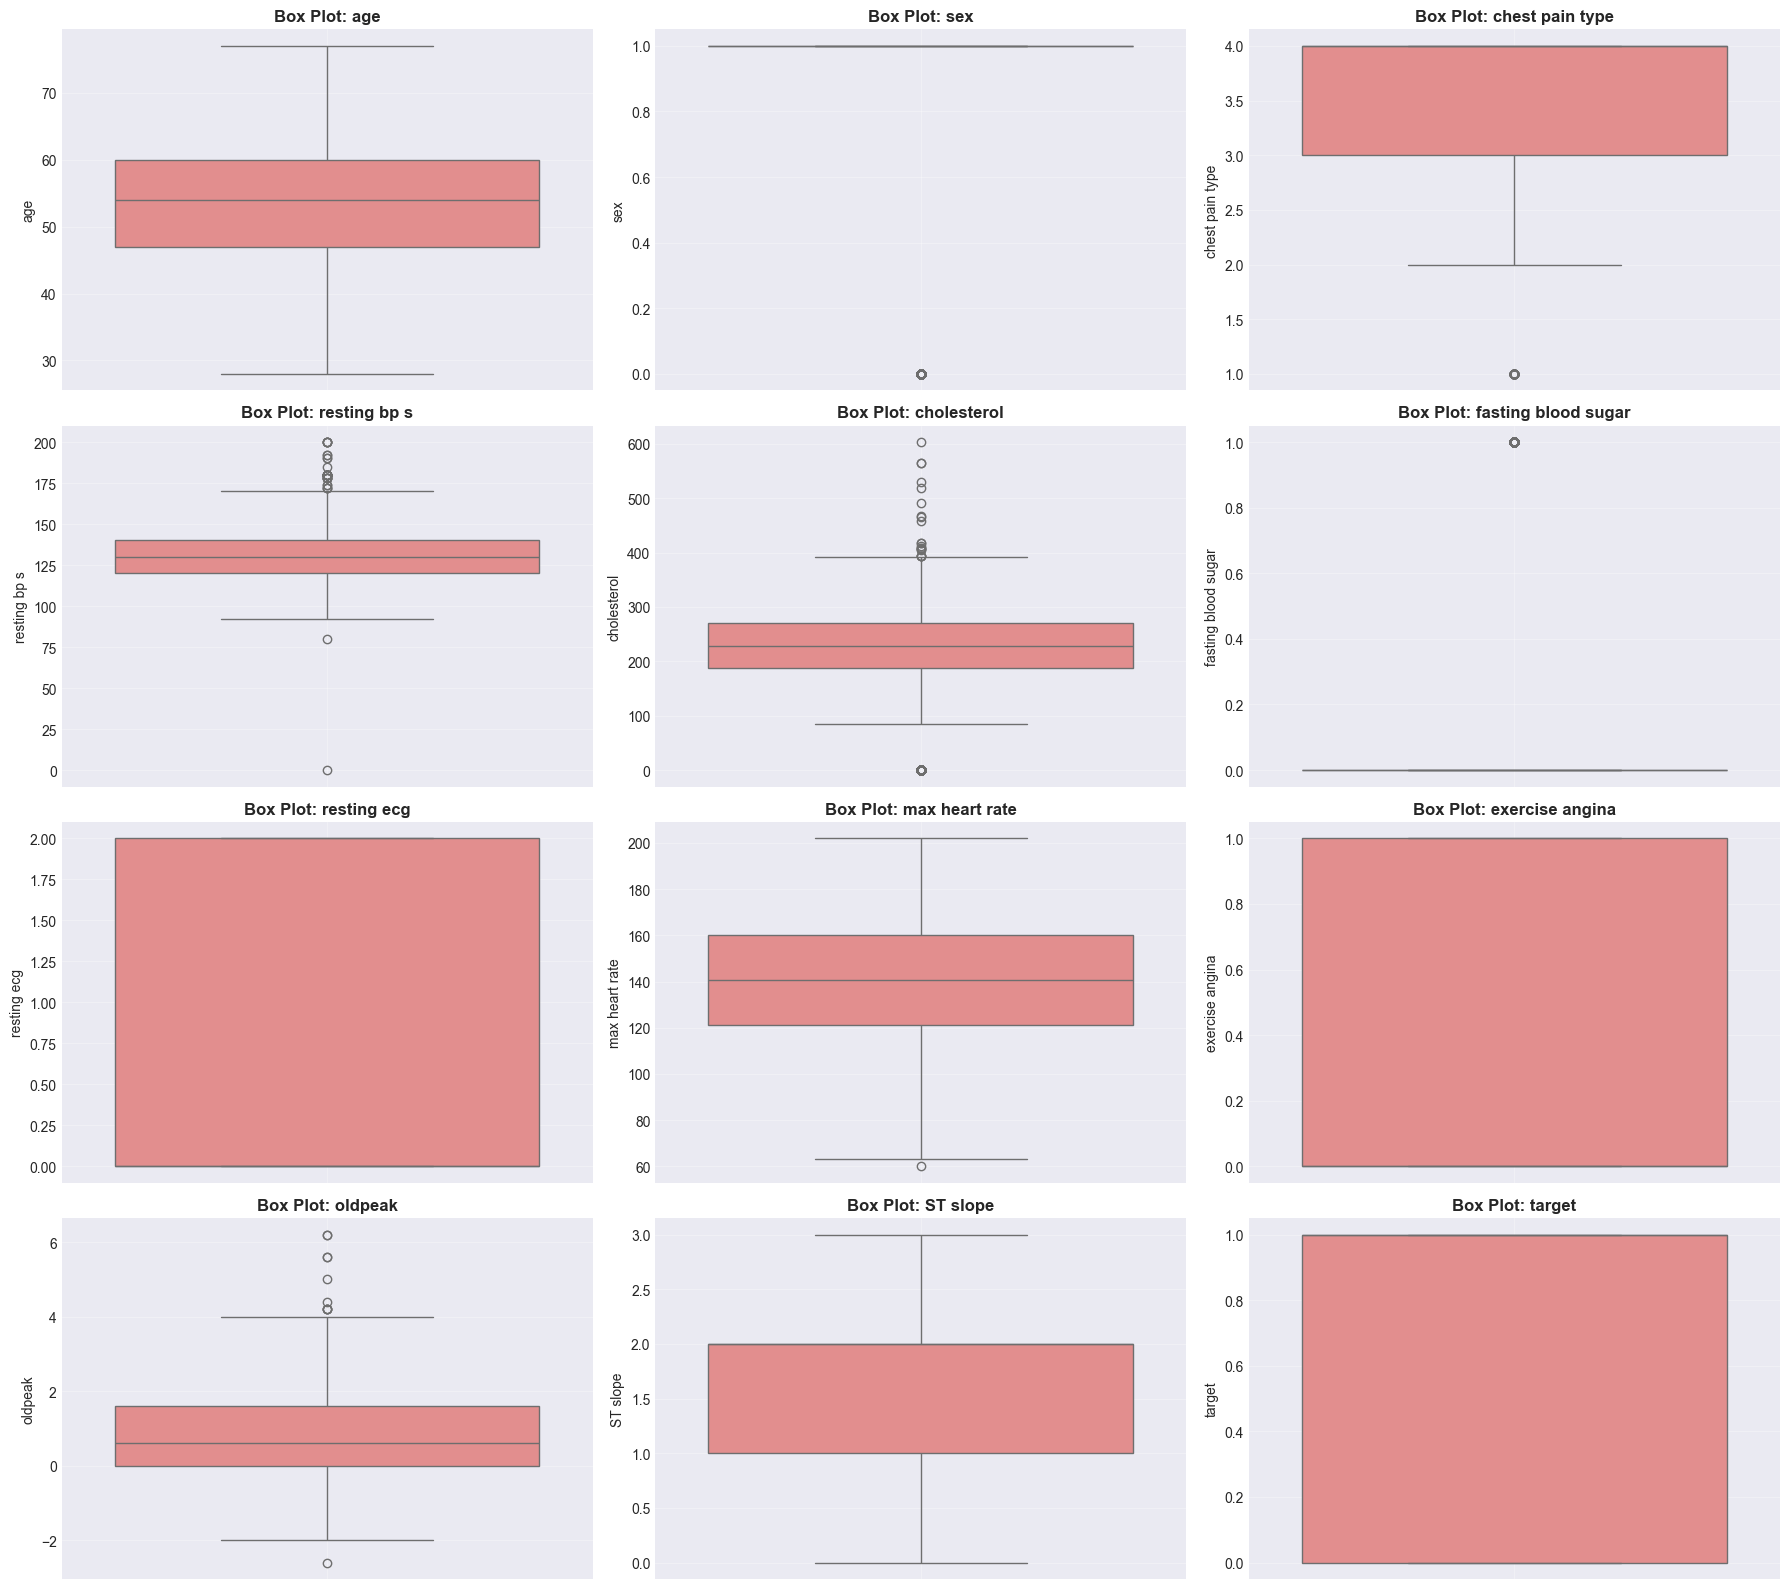

In [22]:
# Box plots for outlier detection
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.boxplot(data=df, y=col, ax=axes[idx], color='lightcoral')
        axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

In [23]:
# Correlation matrix
print("Correlation Matrix:")
print("="*60)
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

Correlation Matrix:
                       age    sex  chest pain type  resting bp s  cholesterol  \
age                  1.000  0.015            0.149         0.258       -0.046   
sex                  0.015  1.000            0.138        -0.006       -0.208   
chest pain type      0.149  0.138            1.000         0.009       -0.109   
resting bp s         0.258 -0.006            0.009         1.000        0.099   
cholesterol         -0.046 -0.208           -0.109         0.099        1.000   
fasting blood sugar  0.179  0.111            0.076         0.088       -0.240   
resting ecg          0.195 -0.022            0.036         0.096        0.151   
max heart rate      -0.369 -0.182           -0.337        -0.101        0.238   
exercise angina      0.188  0.194            0.403         0.142       -0.033   
oldpeak              0.245  0.096            0.224         0.176        0.057   
ST slope             0.238  0.128            0.277         0.089       -0.100   
target  

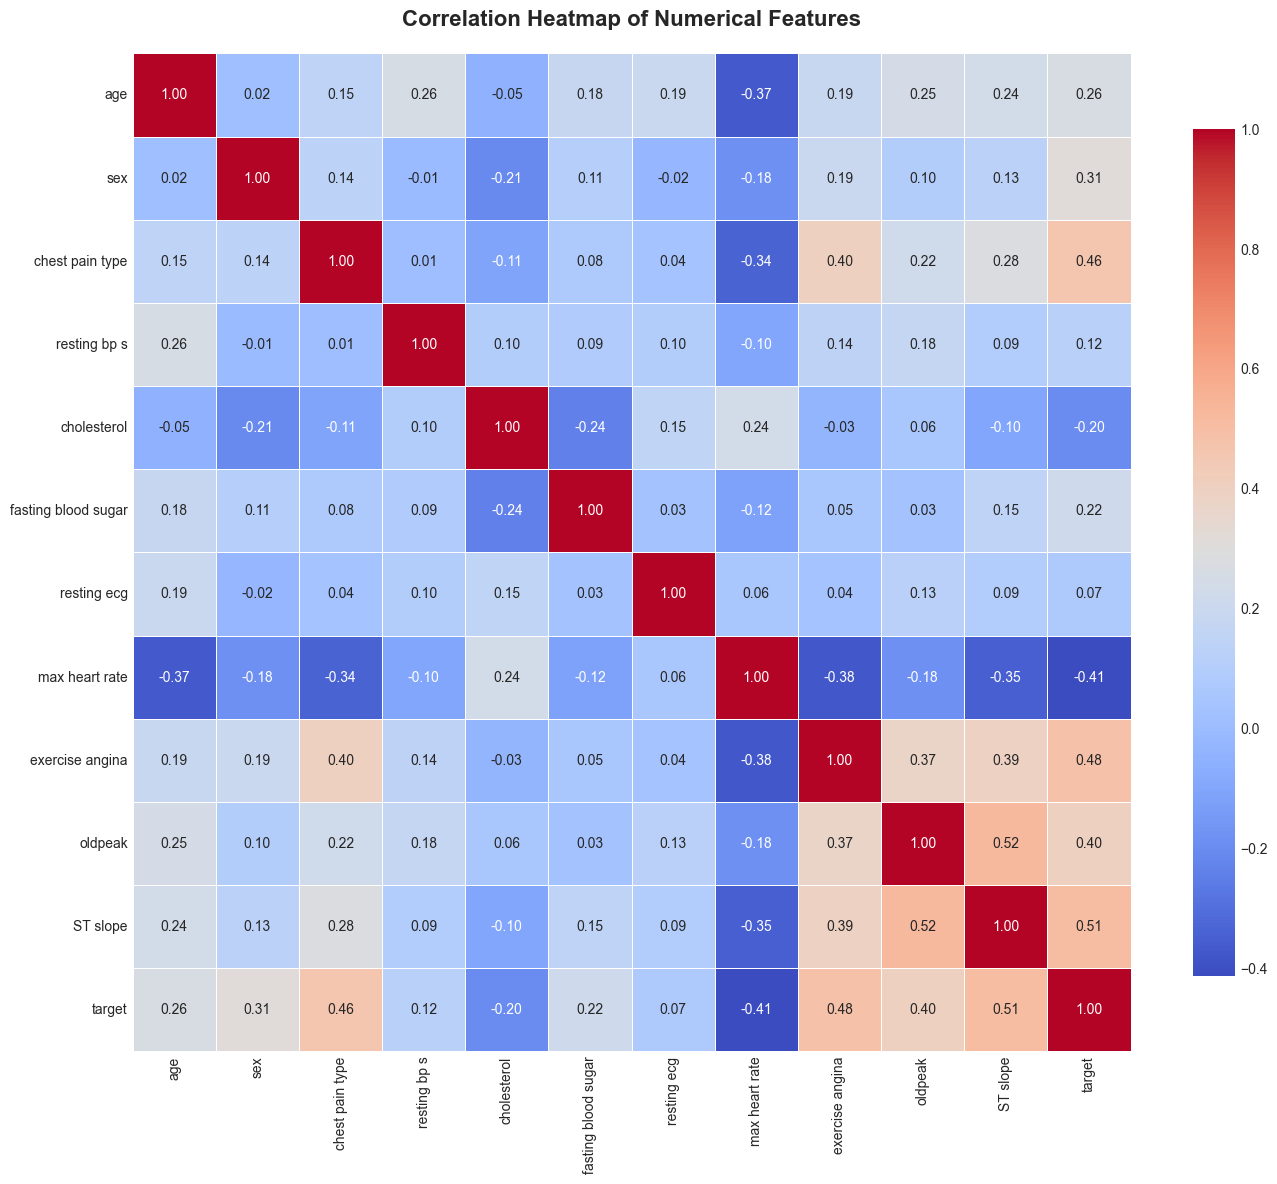

In [24]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Correlation with Target Variable:
target                 1.000
ST slope               0.506
exercise angina        0.481
chest pain type        0.460
oldpeak                0.398
sex                    0.311
age                    0.262
fasting blood sugar    0.217
resting bp s           0.121
resting ecg            0.073
cholesterol           -0.198
max heart rate        -0.413
Name: target, dtype: float64


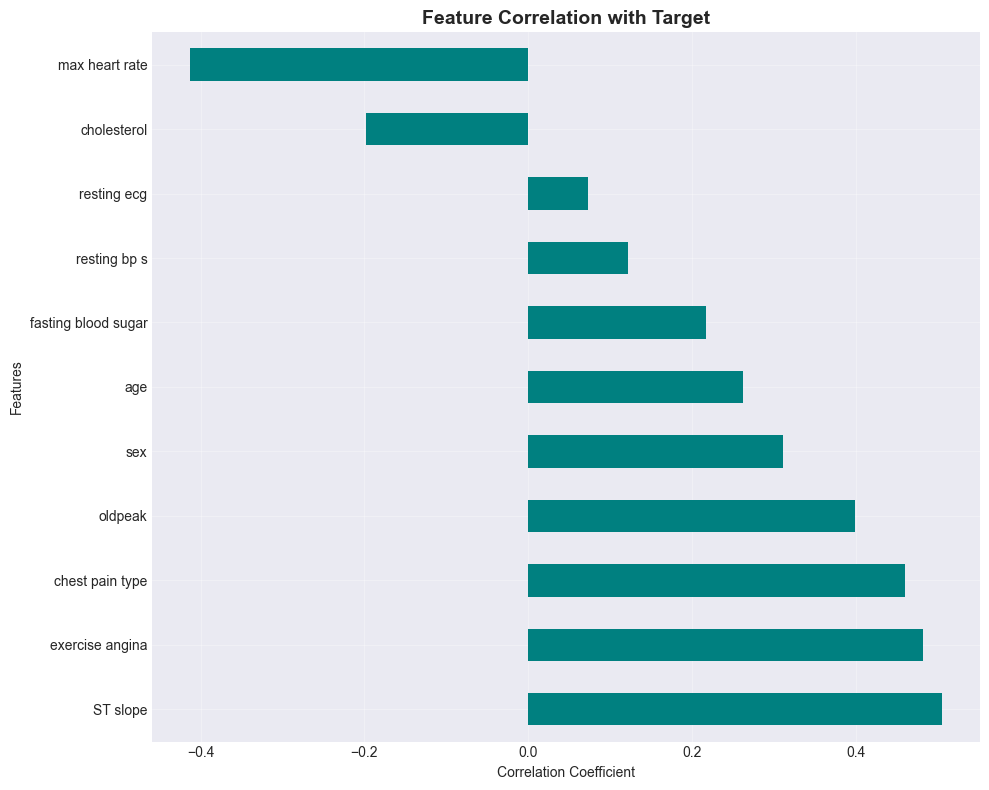

In [25]:
# Correlation with target variable (if 'target' exists)
if 'target' in df.columns:
    target_corr = df[numerical_cols].corr()['target'].sort_values(ascending=False)
    print("Correlation with Target Variable:")
    print("="*60)
    print(target_corr)
    
    # Plot correlation with target
    plt.figure(figsize=(10, 8))
    target_corr.drop('target').plot(kind='barh', color='teal')
    plt.title('Feature Correlation with Target', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Creating pairplot for: ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'target']


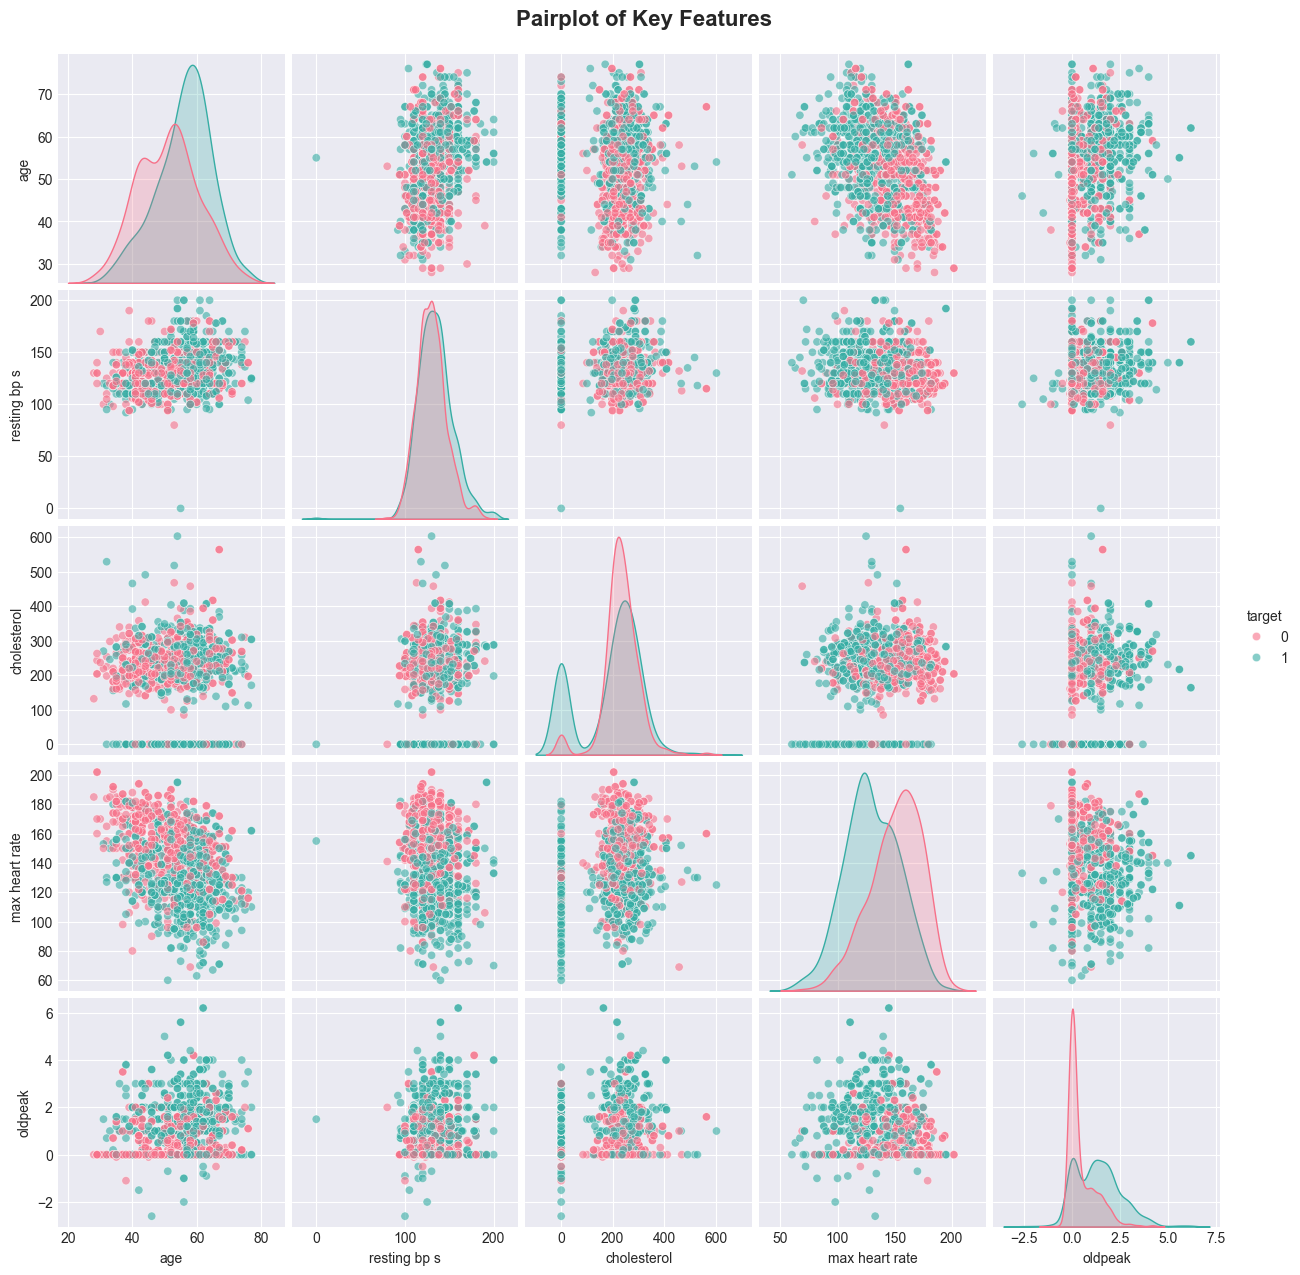

In [26]:
# Pairplot for key numerical features (subset for performance)
key_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
if 'target' in df.columns:
    key_features.append('target')

# Filter features that exist in the dataset
available_features = [f for f in key_features if f in df.columns]

if len(available_features) > 1:
    print(f"Creating pairplot for: {available_features}")
    if 'target' in available_features:
        sns.pairplot(df[available_features], hue='target', palette='husl', 
                     diag_kind='kde', plot_kws={'alpha': 0.6})
    else:
        sns.pairplot(df[available_features], diag_kind='kde', plot_kws={'alpha': 0.6})
    plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=16, fontweight='bold')
    plt.show()

## 7. Univariate Analysis

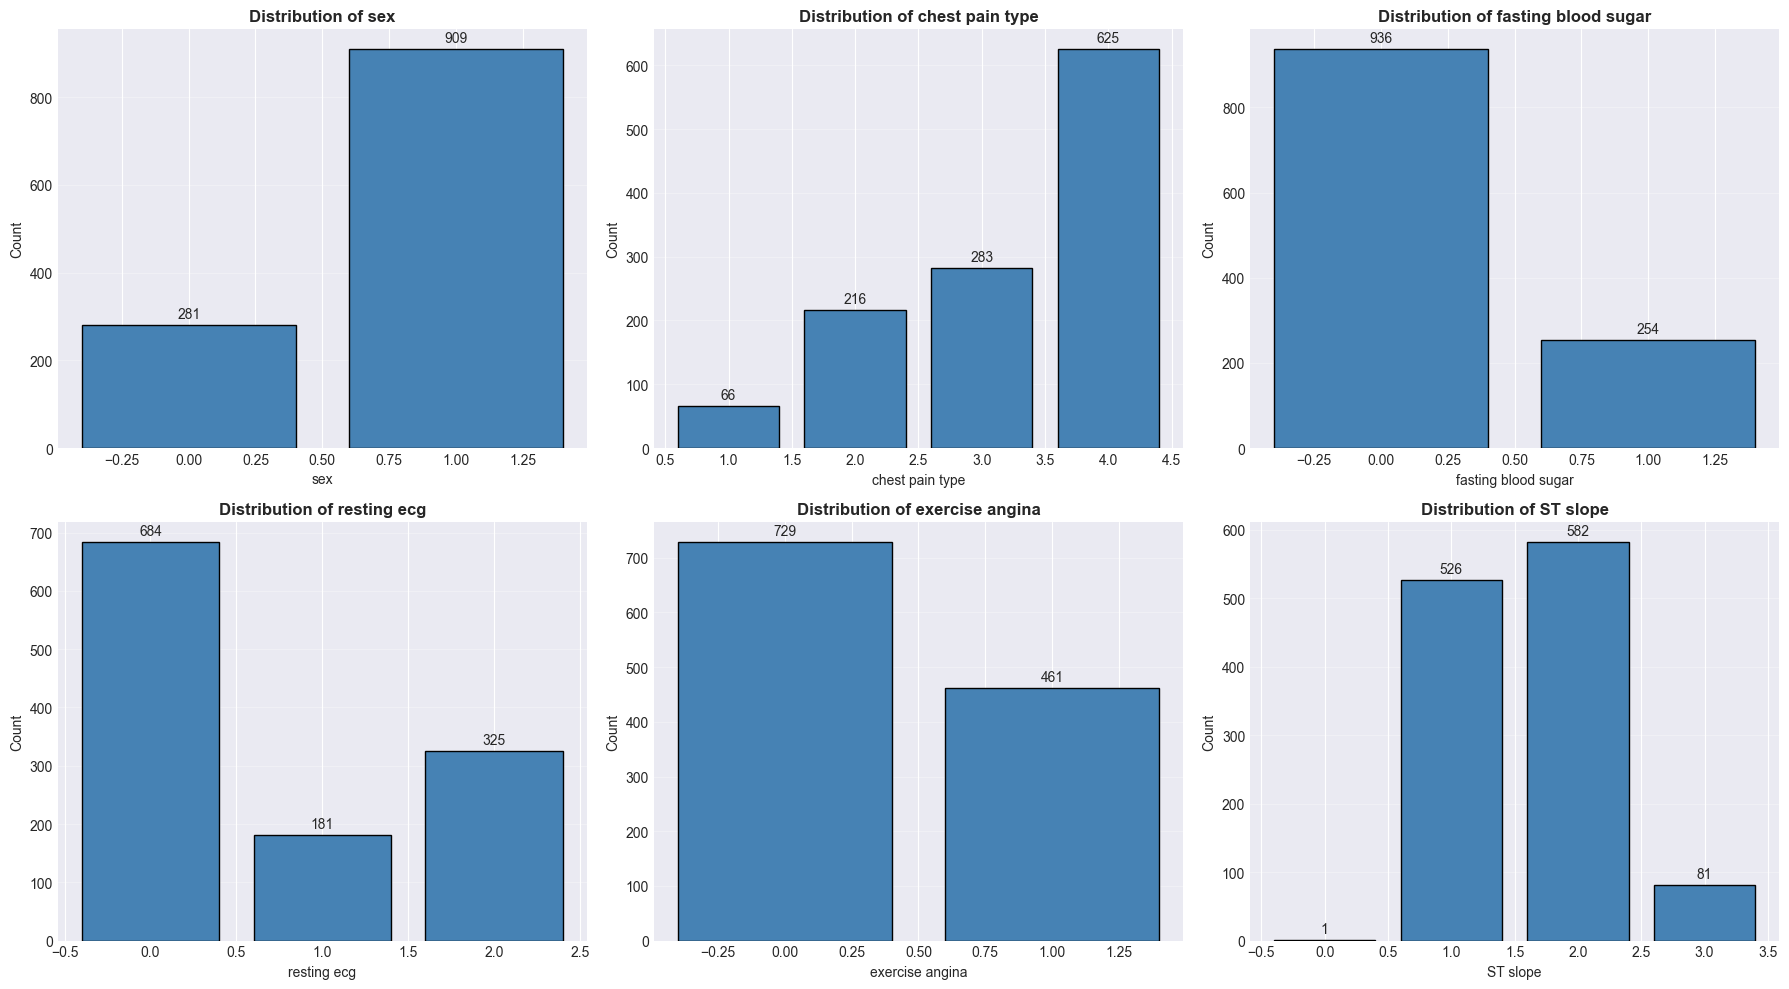

In [27]:
# Univariate analysis for categorical features
categorical_features = ['sex', 'chest pain type', 'fasting blood sugar', 
                        'resting ecg', 'exercise angina', 'ST slope']

# Filter features that exist
available_cat_features = [f for f in categorical_features if f in df.columns]

if available_cat_features:
    n_features = len(available_cat_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*5))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(available_cat_features):
        value_counts = df[col].value_counts()
        axes[idx].bar(value_counts.index, value_counts.values, color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, v in enumerate(value_counts.values):
            axes[idx].text(value_counts.index[i], v + max(value_counts.values)*0.01, 
                          str(v), ha='center', va='bottom')
    
    # Remove empty subplots
    for idx in range(len(available_cat_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

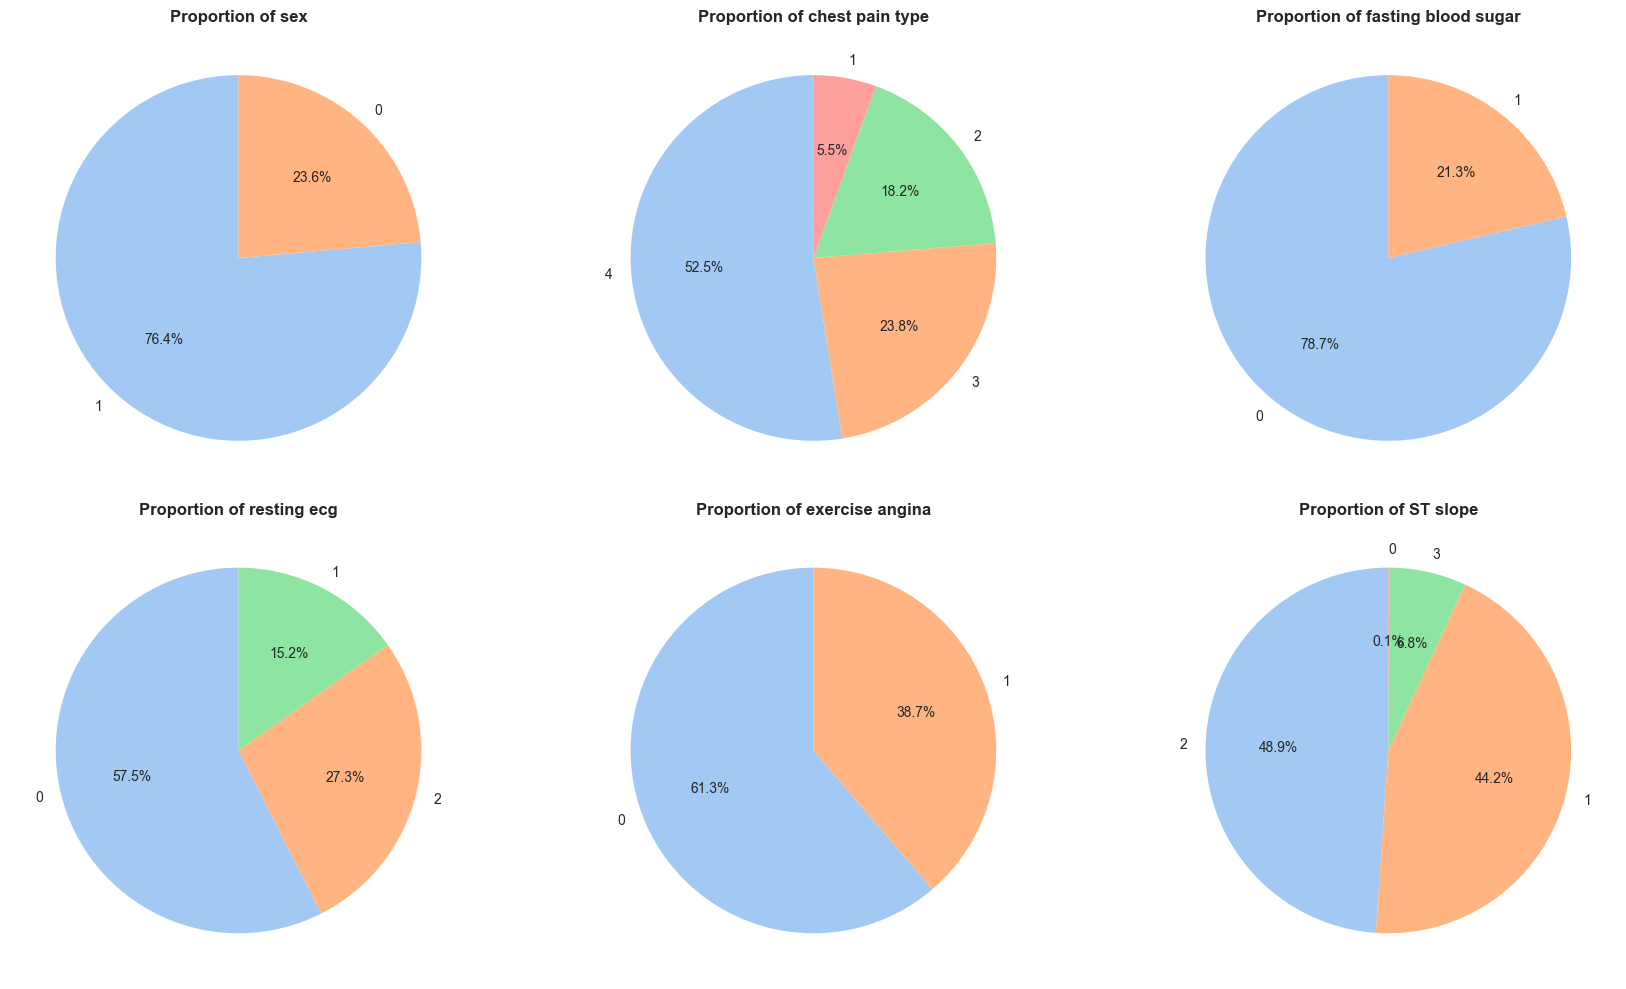

In [28]:
# Pie charts for categorical features
if available_cat_features:
    n_features = len(available_cat_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*5))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(available_cat_features):
        value_counts = df[col].value_counts()
        axes[idx].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
                     startangle=90, colors=sns.color_palette('pastel'))
        axes[idx].set_title(f'Proportion of {col}', fontsize=12, fontweight='bold')
    
    # Remove empty subplots
    for idx in range(len(available_cat_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

In [29]:
# Statistical summary for each categorical feature
print("Categorical Features Summary:")
print("="*60)
for col in available_cat_features:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")

Categorical Features Summary:

sex:
sex
1    909
0    281
Name: count, dtype: int64
Unique values: 2

chest pain type:
chest pain type
4    625
3    283
2    216
1     66
Name: count, dtype: int64
Unique values: 4

fasting blood sugar:
fasting blood sugar
0    936
1    254
Name: count, dtype: int64
Unique values: 2

resting ecg:
resting ecg
0    684
2    325
1    181
Name: count, dtype: int64
Unique values: 3

exercise angina:
exercise angina
0    729
1    461
Name: count, dtype: int64
Unique values: 2

ST slope:
ST slope
2    582
1    526
3     81
0      1
Name: count, dtype: int64
Unique values: 4


## 8. Bivariate Analysis

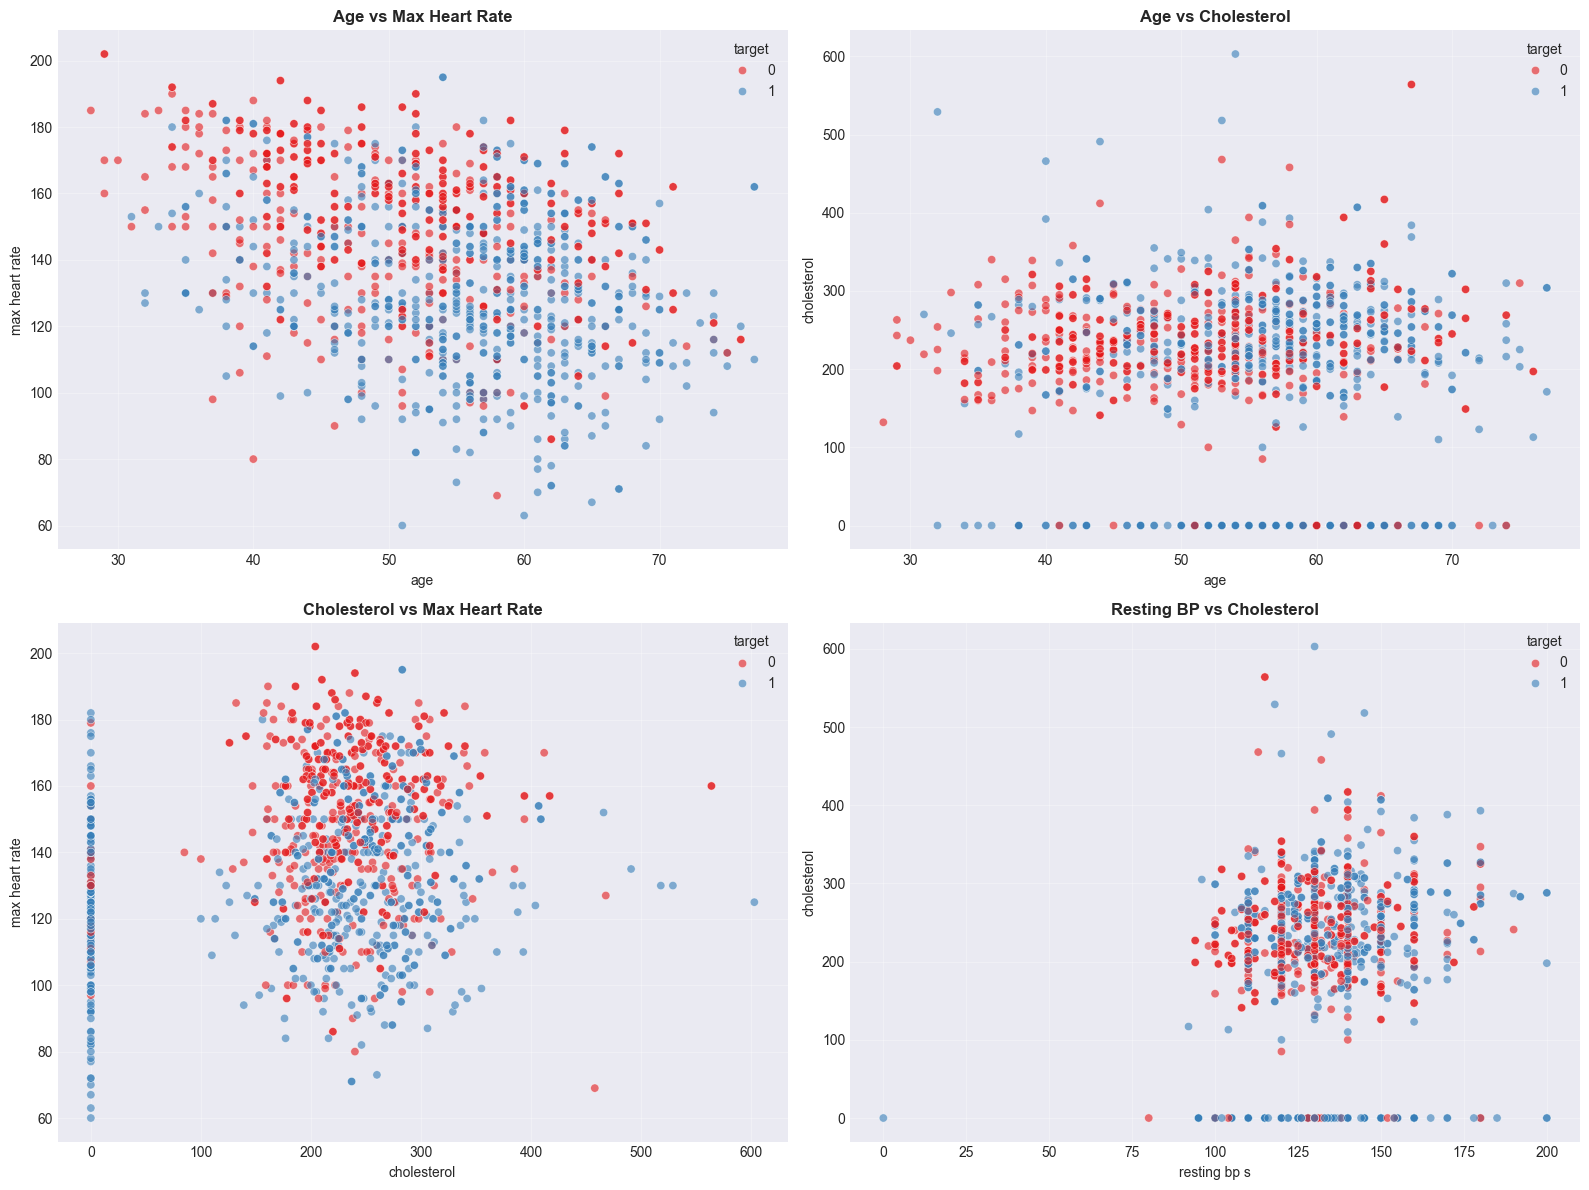

In [30]:
# Scatter plots between key numerical features
if 'age' in df.columns and 'max heart rate' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Age vs Max Heart Rate
    if 'target' in df.columns:
        sns.scatterplot(data=df, x='age', y='max heart rate', hue='target', 
                       palette='Set1', alpha=0.6, ax=axes[0, 0])
    else:
        sns.scatterplot(data=df, x='age', y='max heart rate', alpha=0.6, ax=axes[0, 0])
    axes[0, 0].set_title('Age vs Max Heart Rate', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Age vs Cholesterol
    if 'cholesterol' in df.columns:
        if 'target' in df.columns:
            sns.scatterplot(data=df, x='age', y='cholesterol', hue='target', 
                           palette='Set1', alpha=0.6, ax=axes[0, 1])
        else:
            sns.scatterplot(data=df, x='age', y='cholesterol', alpha=0.6, ax=axes[0, 1])
        axes[0, 1].set_title('Age vs Cholesterol', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Cholesterol vs Max Heart Rate
    if 'cholesterol' in df.columns:
        if 'target' in df.columns:
            sns.scatterplot(data=df, x='cholesterol', y='max heart rate', hue='target', 
                           palette='Set1', alpha=0.6, ax=axes[1, 0])
        else:
            sns.scatterplot(data=df, x='cholesterol', y='max heart rate', alpha=0.6, ax=axes[1, 0])
        axes[1, 0].set_title('Cholesterol vs Max Heart Rate', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Resting BP vs Cholesterol
    if 'resting bp s' in df.columns and 'cholesterol' in df.columns:
        if 'target' in df.columns:
            sns.scatterplot(data=df, x='resting bp s', y='cholesterol', hue='target', 
                           palette='Set1', alpha=0.6, ax=axes[1, 1])
        else:
            sns.scatterplot(data=df, x='resting bp s', y='cholesterol', alpha=0.6, ax=axes[1, 1])
        axes[1, 1].set_title('Resting BP vs Cholesterol', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 9. Target Variable Analysis

Target Variable Distribution:
target
1    629
0    561
Name: count, dtype: int64

Target proportions:
target
1   52.857
0   47.143
Name: proportion, dtype: float64


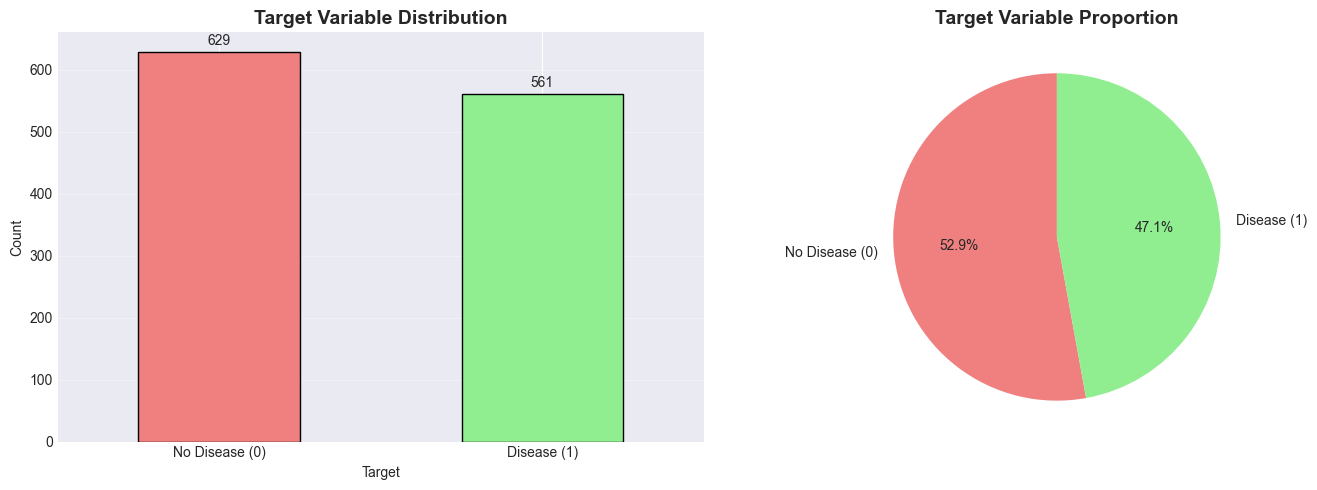

In [31]:
# Target variable distribution
if 'target' in df.columns:
    print("Target Variable Distribution:")
    print("="*60)
    target_counts = df['target'].value_counts()
    print(target_counts)
    print(f"\nTarget proportions:")
    print(df['target'].value_counts(normalize=True) * 100)
    
    # Visualize target distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    target_counts.plot(kind='bar', ax=axes[0], color=['lightcoral', 'lightgreen'], edgecolor='black')
    axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Target')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, v in enumerate(target_counts.values):
        axes[0].text(i, v + max(target_counts.values)*0.01, str(v), ha='center', va='bottom')
    
    # Pie chart
    axes[1].pie(target_counts.values, labels=['No Disease (0)', 'Disease (1)'], 
               autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
    axes[1].set_title('Target Variable Proportion', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

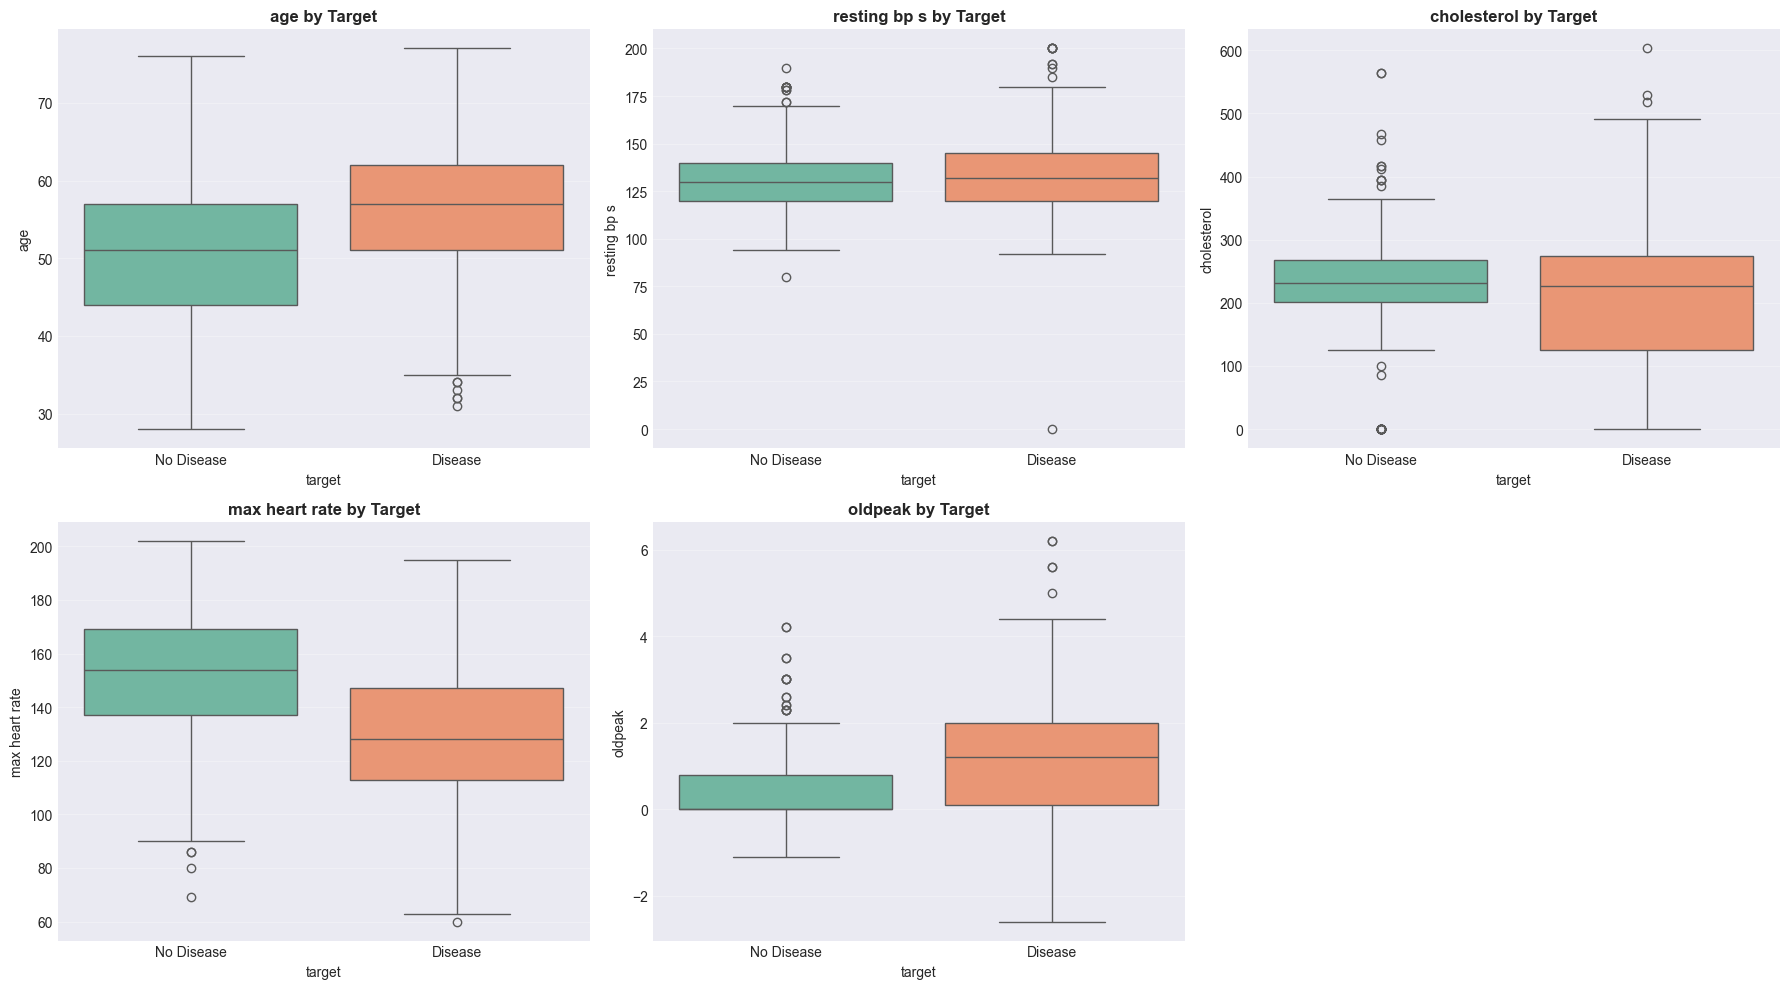

In [32]:
# Feature distributions by target
if 'target' in df.columns:
    key_num_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
    available_num_features = [f for f in key_num_features if f in df.columns]
    
    if available_num_features:
        n_features = len(available_num_features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*5))
        axes = axes.flatten() if n_features > 1 else [axes]
        
        for idx, col in enumerate(available_num_features):
            sns.boxplot(data=df, x='target', y=col, palette='Set2', ax=axes[idx])
            axes[idx].set_title(f'{col} by Target', fontsize=12, fontweight='bold')
            axes[idx].set_xticklabels(['No Disease', 'Disease'])
            axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Remove empty subplots
        for idx in range(len(available_num_features), len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        plt.show()

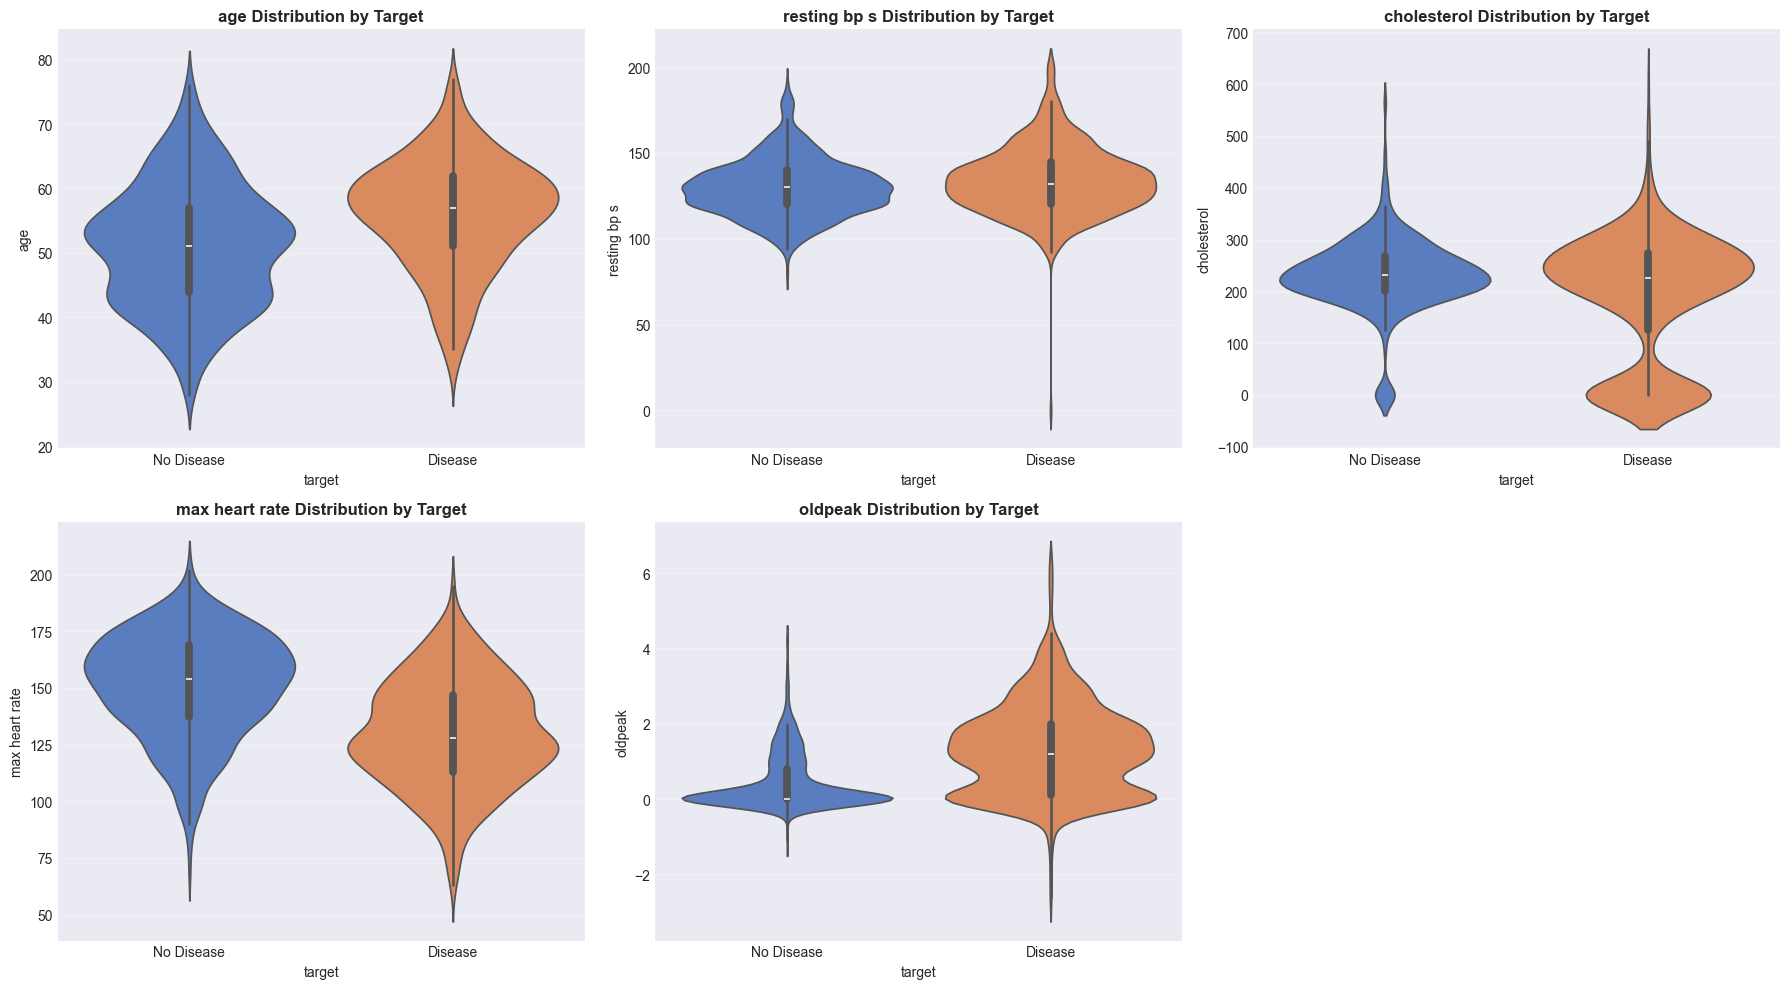

In [33]:
# Violin plots for numerical features by target
if 'target' in df.columns and available_num_features:
    n_features = len(available_num_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*5))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(available_num_features):
        sns.violinplot(data=df, x='target', y=col, palette='muted', ax=axes[idx])
        axes[idx].set_title(f'{col} Distribution by Target', fontsize=12, fontweight='bold')
        axes[idx].set_xticklabels(['No Disease', 'Disease'])
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Remove empty subplots
    for idx in range(len(available_num_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

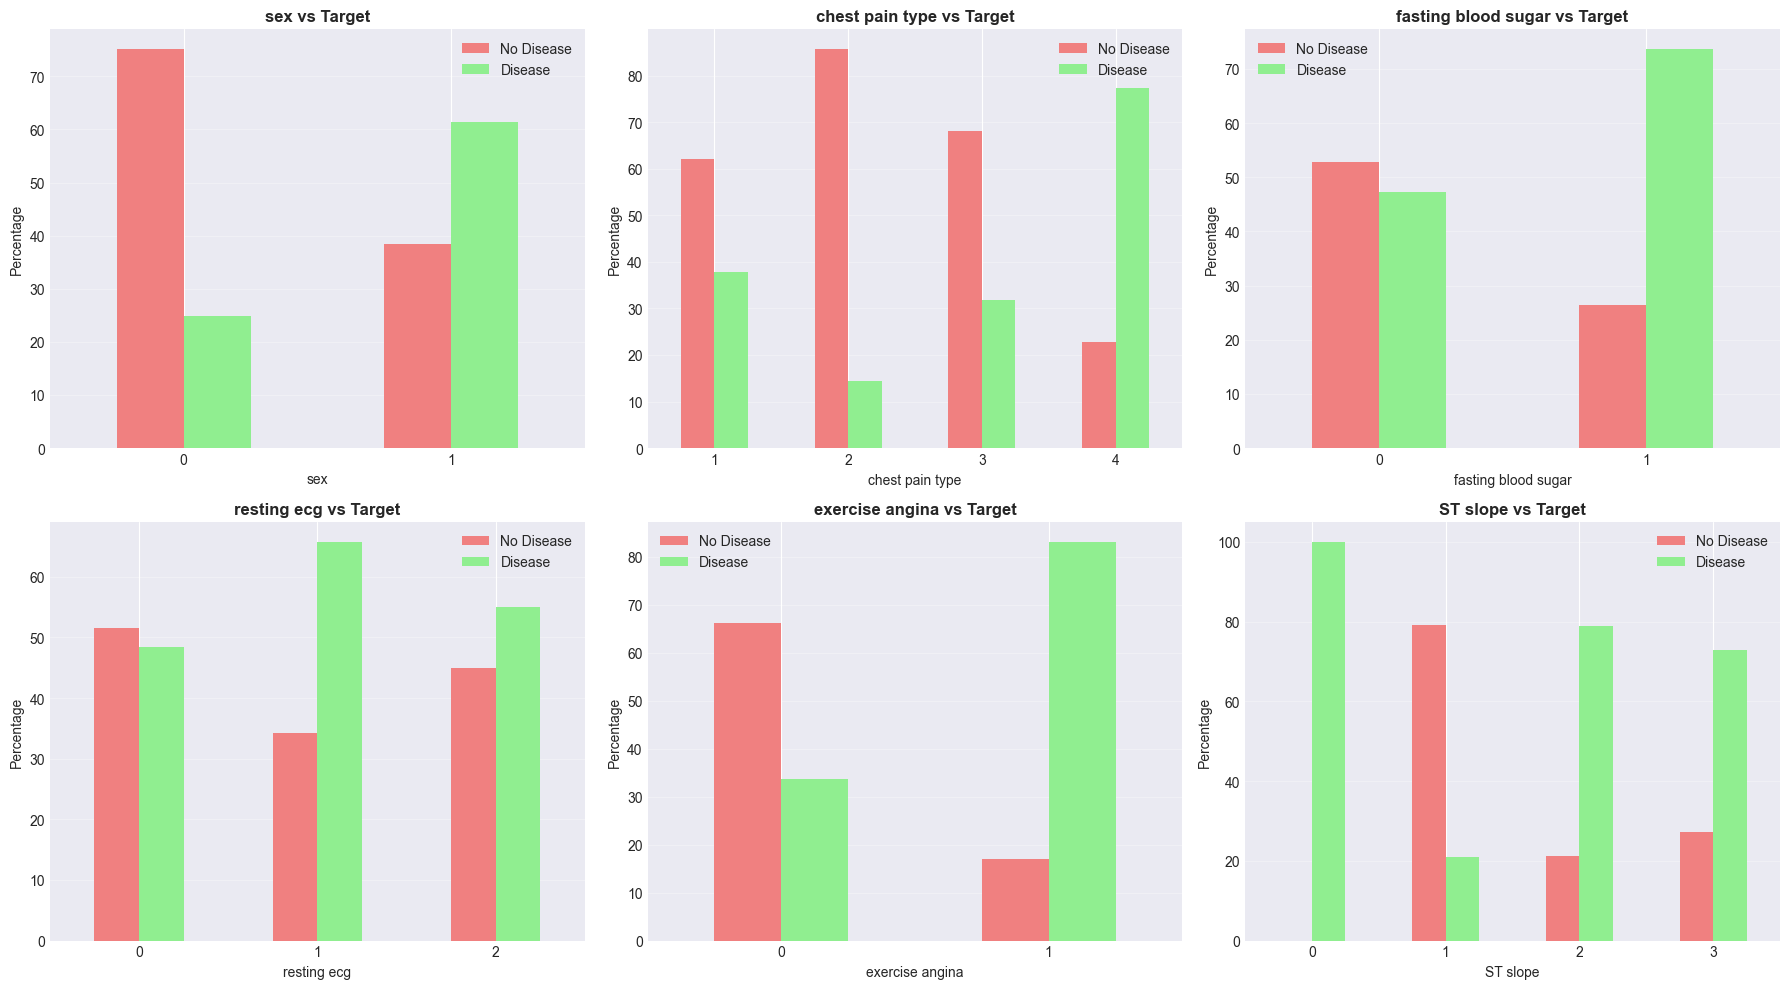

In [34]:
# Categorical features vs target
if 'target' in df.columns and available_cat_features:
    n_features = len(available_cat_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows*5))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(available_cat_features):
        cross_tab = pd.crosstab(df[col], df['target'], normalize='index') * 100
        cross_tab.plot(kind='bar', stacked=False, ax=axes[idx], color=['lightcoral', 'lightgreen'])
        axes[idx].set_title(f'{col} vs Target', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Percentage')
        axes[idx].legend(['No Disease', 'Disease'])
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    
    # Remove empty subplots
    for idx in range(len(available_cat_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

## 10. Insights and Conclusions

In [35]:
# Summary statistics by target
if 'target' in df.columns:
    print("Summary Statistics by Target:")
    print("="*60)
    print("\nNo Disease (target = 0):")
    print(df[df['target'] == 0].describe())
    print("\n" + "="*60)
    print("\nDisease (target = 1):")
    print(df[df['target'] == 1].describe())

Summary Statistics by Target:

No Disease (target = 0):
          age     sex  chest pain type  resting bp s  cholesterol  \
count 561.000 561.000          561.000       561.000      561.000   
mean   51.125   0.624            2.777       129.793      231.658   
std     9.494   0.485            0.909        16.490       70.022   
min    28.000   0.000            1.000        80.000        0.000   
25%    44.000   0.000            2.000       120.000      201.000   
50%    51.000   1.000            3.000       130.000      232.000   
75%    57.000   1.000            4.000       140.000      268.000   
max    76.000   1.000            4.000       190.000      564.000   

       fasting blood sugar  resting ecg  max heart rate  exercise angina  \
count              561.000      561.000         561.000          561.000   
mean                 0.119        0.631         150.895            0.139   
std                  0.325        0.869          22.705            0.346   
min               

In [36]:
# Key observations
print("Key Observations from EDA:")
print("="*60)
print(f"1. Dataset size: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"2. Missing values: {df.isnull().sum().sum()}")
print(f"3. Duplicate rows: {df.duplicated().sum()}")

if 'target' in df.columns:
    target_balance = df['target'].value_counts(normalize=True) * 100
    print(f"4. Target variable balance:")
    print(f"   - No Disease (0): {target_balance[0]:.2f}%")
    print(f"   - Disease (1): {target_balance[1]:.2f}%")
    
    if abs(target_balance[0] - target_balance[1]) > 10:
        print("   ⚠ Note: Dataset shows some class imbalance")
    else:
        print("   ✓ Dataset is relatively balanced")

print(f"\n5. Numerical features: {len(numerical_cols)}")
print(f"6. Categorical features: {len(categorical_cols) if categorical_cols else 0}")

# Check for outliers
print(f"\n7. Potential outliers detected (based on IQR method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"   - {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

Key Observations from EDA:
1. Dataset size: 1190 rows and 12 columns
2. Missing values: 0
3. Duplicate rows: 272
4. Target variable balance:
   - No Disease (0): 47.14%
   - Disease (1): 52.86%
   ✓ Dataset is relatively balanced

5. Numerical features: 12
6. Categorical features: 0

7. Potential outliers detected (based on IQR method):
   - sex: 281 outliers (23.61%)
   - chest pain type: 66 outliers (5.55%)
   - resting bp s: 37 outliers (3.11%)
   - cholesterol: 193 outliers (16.22%)
   - fasting blood sugar: 254 outliers (21.34%)
   - max heart rate: 1 outliers (0.08%)
   - oldpeak: 11 outliers (0.92%)


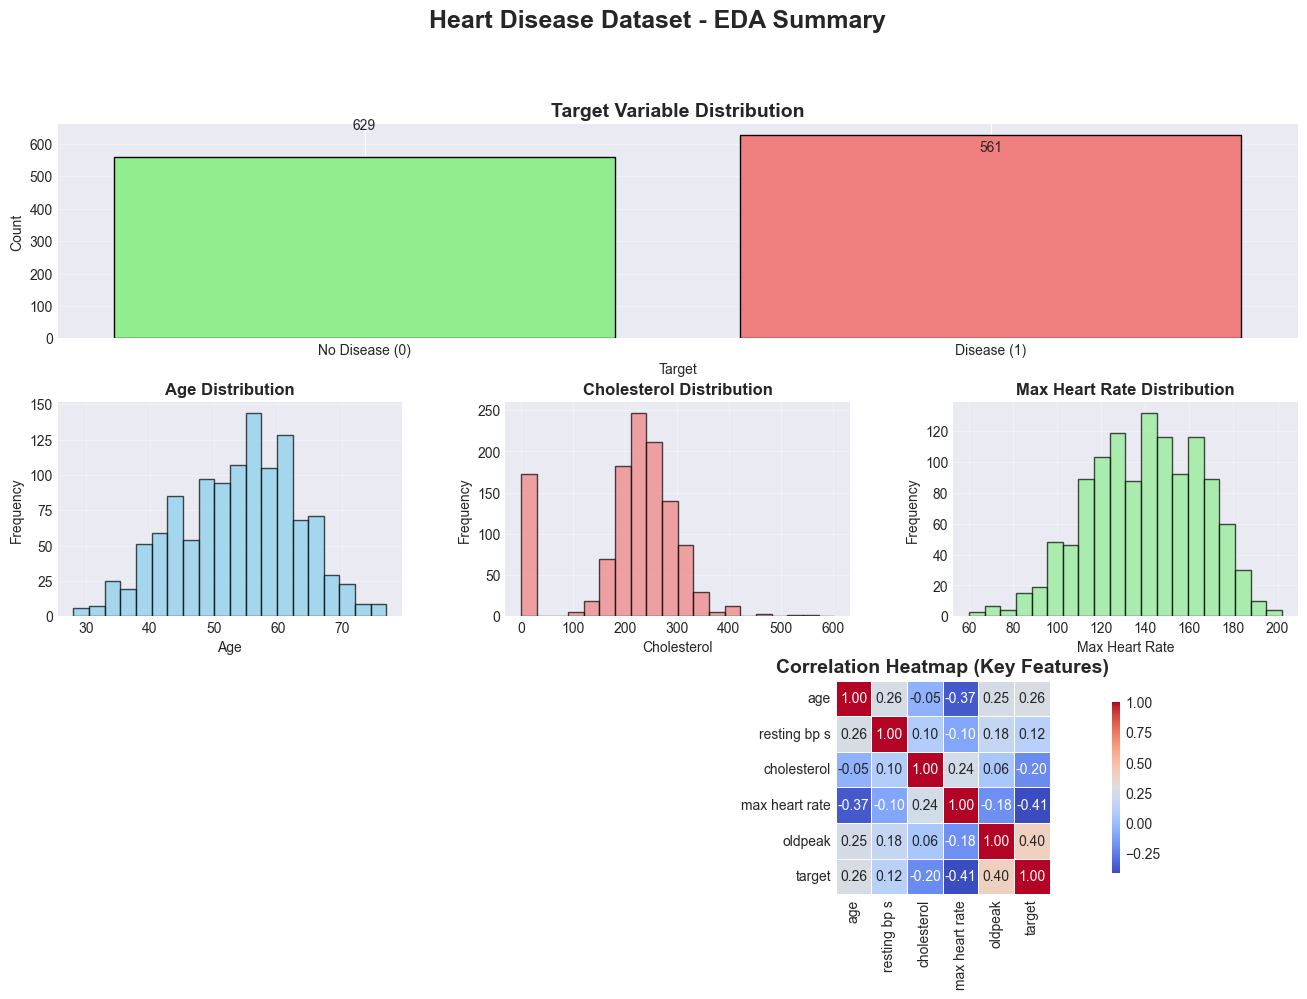

In [37]:
# Final summary visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Target distribution
if 'target' in df.columns:
    ax1 = fig.add_subplot(gs[0, :])
    target_counts = df['target'].value_counts()
    ax1.bar(target_counts.index, target_counts.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
    ax1.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Target')
    ax1.set_ylabel('Count')
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(['No Disease (0)', 'Disease (1)'])
    ax1.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(target_counts.values):
        ax1.text(i, v + max(target_counts.values)*0.01, str(v), ha='center', va='bottom')

# Age distribution
if 'age' in df.columns:
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.hist(df['age'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)
    ax2.set_title('Age Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Age')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)

# Cholesterol distribution
if 'cholesterol' in df.columns:
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(df['cholesterol'], bins=20, edgecolor='black', color='lightcoral', alpha=0.7)
    ax3.set_title('Cholesterol Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cholesterol')
    ax3.set_ylabel('Frequency')
    ax3.grid(True, alpha=0.3)

# Max heart rate distribution
if 'max heart rate' in df.columns:
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.hist(df['max heart rate'], bins=20, edgecolor='black', color='lightgreen', alpha=0.7)
    ax4.set_title('Max Heart Rate Distribution', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Max Heart Rate')
    ax4.set_ylabel('Frequency')
    ax4.grid(True, alpha=0.3)

# Correlation heatmap (subset)
ax5 = fig.add_subplot(gs[2, :])
subset_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
if 'target' in df.columns:
    subset_features.append('target')
available_subset = [f for f in subset_features if f in df.columns]
if len(available_subset) > 1:
    corr_subset = df[available_subset].corr()
    sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt='.2f', 
                linewidths=0.5, square=True, ax=ax5, cbar_kws={"shrink": 0.8})
    ax5.set_title('Correlation Heatmap (Key Features)', fontsize=14, fontweight='bold')

plt.suptitle('Heart Disease Dataset - EDA Summary', fontsize=18, fontweight='bold', y=0.995)
plt.show()